The Image classification model

In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten , BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

In [ ]:
# Data Preparation and Exploration

In [ ]:
(X_train,y_train),(X_test , y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [ ]:
X_train.shape, y_train.shape

((45000, 32, 32, 3), (45000, 1))

In [ ]:
X_test.shape, y_test.shape

((10000, 32, 32, 3), (10000, 1))

In [ ]:
X_valid.shape, y_valid.shape

((5000, 32, 32, 3), (5000, 1))

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

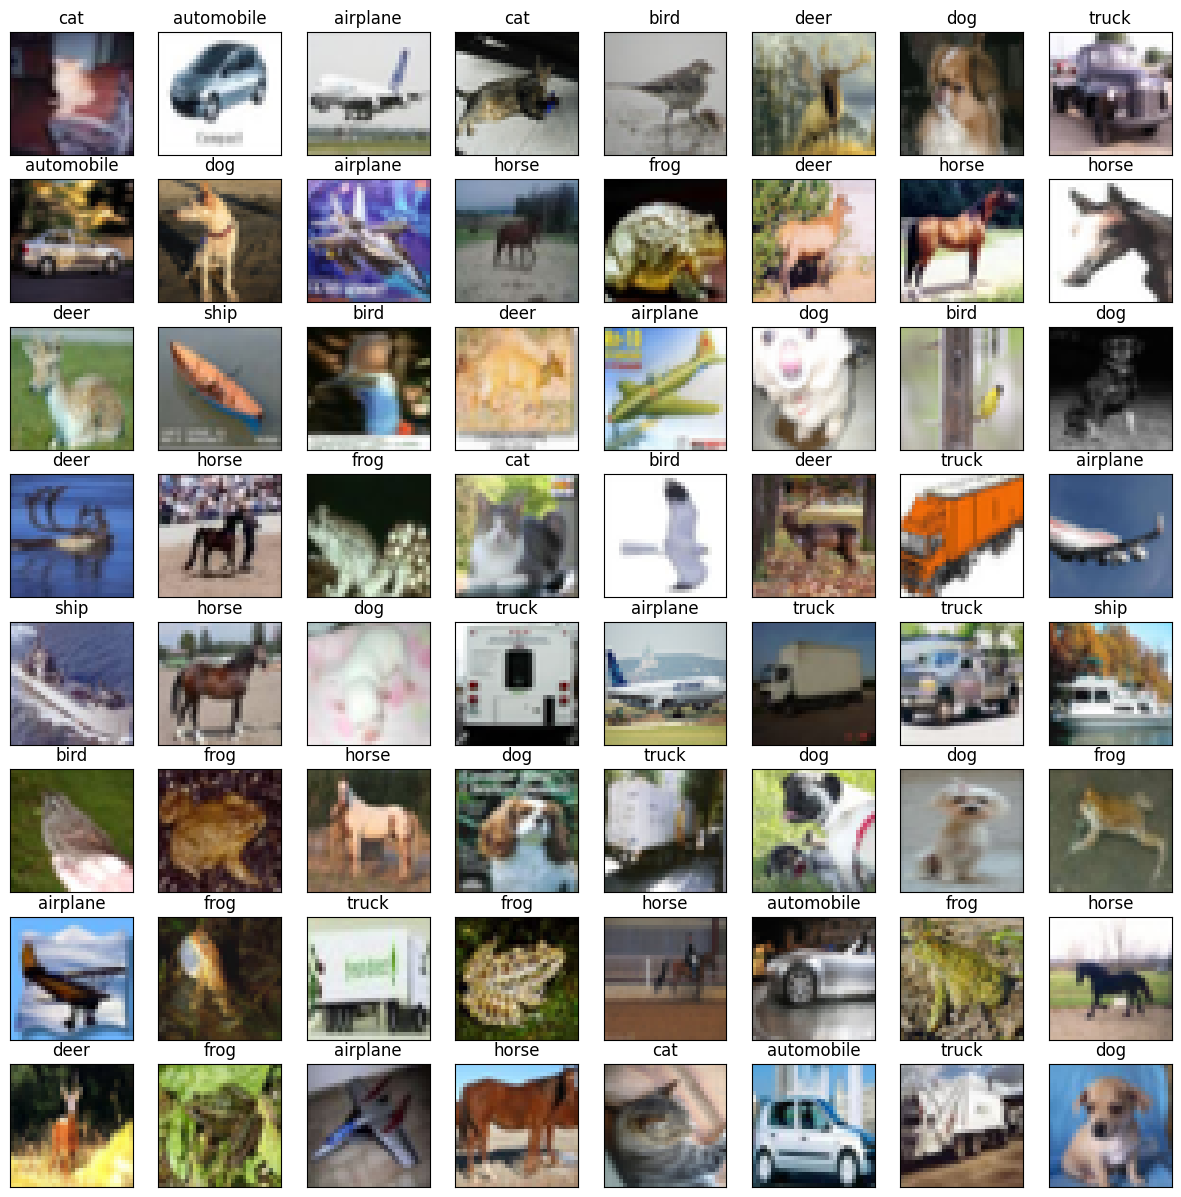

In [ ]:
plt.figure(figsize=(15,15))
for i in range(64):
  plt.subplot(8,8,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(X_train[i])
  plt.title(class_names[y_train[i][0]])

# Data Preprocessing
1. Normalisation of Image
2. One hot encoding of labels
3. data Augmentation


# Normalisation

In [ ]:
# converting pixel values to float32
X_train = X_train.astype('float32')
X_valid = X_valid.astype('float32')
X_test = X_test.astype('float32')

# calculating the mean and std of training images
mean = np.mean(X_train)
std = np.std(X_train)

# normalising the images
X_train = (X_train - mean) / (std+.00000001)
X_valid = (X_valid - mean) / (std+.00000001)
X_test = (X_test - mean) / (std+.00000001)

One Hot Encoding of Labels

In [ ]:
y_train = to_categorical(y_train, num_classes=10)
y_valid = to_categorical(y_valid, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

### Data Augmentation

In [ ]:
data_generator  = ImageDataGenerator(
    rotation_range= 15 ,#rotation images by up tp 15 degree
    width_shift_range = .12, # shift images horizontally by upto 12% of width
    height_shift_range = .12, # shift images vertically by upto 12% of height
    horizontal_flip = True, # flip images horizontally
    zoom_range = 0.1, # zoom images by upto 10%
    brightness_range = (0.9, 1.1) ,# adjust brightness by upto 10%
    shear_range = 10, # shear images by upto 10 degrees
    channel_shift_range = 0.1

)




# Model Architecture

In [ ]:
model = Sequential()
weight_decay = 0.0001 # weight decay for l2 regularization
model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'same', activation = 'relu',kernel_regularizer = l2(weight_decay), input_shape = X_train.shape[1:]))
model.add(BatchNormalization())

model.add(Conv2D(filters = 32, kernel_size = (3,3), padding = 'same', activation = 'relu',kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())

# add first max pooling layer with pool size of 2*2
model.add(MaxPooling2D(pool_size = (2,2)))
# add droupout layer with 0.2 dropout rate
model.add(Dropout(rate = 0.2))

# Add the third and fourth  Conv layers
model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'same', activation = 'relu',kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())

model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = 'same', activation = 'relu',kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())

# add 2nd  max pooling layer with pool size of 2*2
model.add(MaxPooling2D(pool_size = (2,2)))
# add droupout layer with 0.3 dropout rate
model.add(Dropout(rate = 0.3))

# add the fifth and six convolutional layers
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = 'same', activation = 'relu',kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())

model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = 'same', activation = 'relu',kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())


# add 3rd  max pooling layer with pool size of 2*2
model.add(MaxPooling2D(pool_size = (2,2)))
# add droupout layer with 0.4 dropout rate
model.add(Dropout(rate = 0.4))


# add the seven  and eight  convolutional layers
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = 'same', activation = 'relu',kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())

model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = 'same', activation = 'relu',kernel_regularizer = l2(weight_decay)))
model.add(BatchNormalization())

# add 4rd  max pooling layer with pool size of 2*2
model.add(MaxPooling2D(pool_size = (2,2)))
# add droupout layer with 0.5 dropout rate
model.add(Dropout(rate = 0.5))


#flatten the tensor output from the previous layer
model.add(Flatten())
# add the fully connected layer with softmax activation function
model.add(Dense(10,activation = 'softmax'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,186,346 (4.53 MB)

 Trainable params: 1,184,426 (4.52 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
#Set the batch size
batch_size = 64
epochs = 150 # you can use the 300/400 instread of 150 for more accuracy

optimizer =  Adam(learning_rate =0.0005)

model.compile(optimizer = optimizer, loss = 'categorical_crossentropy', metrics = ['accuracy'])

reduce_lr = ReduceLROnPlateau ( monitor = 'val_loss', factor = 0.5, patience = 10 , min_lr = .00001 )

early_stopping = EarlyStopping(monitor = 'val_loss', patience = 40, restore_best_weights = True , verbose =1)

## feeding the data and traing the model
model.fit(data_generator.flow(X_train , y_train , batch_size = batch_size),
                              epochs = epochs,
                              validation_data = (X_valid, y_valid),
                              callbacks = [reduce_lr, early_stopping],
                              verbose = 2 )


Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


704/704 - 75s - 107ms/step - accuracy: 0.3429 - loss: 2.3046 - val_accuracy: 0.4456 - val_loss: 1.6515 - learning_rate: 5.0000e-04
Epoch 2/150
704/704 - 46s - 65ms/step - accuracy: 0.4663 - loss: 1.7469 - val_accuracy: 0.4644 - val_loss: 2.5605 - learning_rate: 5.0000e-04
Epoch 3/150
704/704 - 45s - 64ms/step - accuracy: 0.5352 - loss: 1.5184 - val_accuracy: 0.6010 - val_loss: 1.2819 - learning_rate: 5.0000e-04
Epoch 4/150
704/704 - 42s - 59ms/step - accuracy: 0.5833 - loss: 1.3644 - val_accuracy: 0.6690 - val_loss: 1.1108 - learning_rate: 5.0000e-04
Epoch 5/150
704/704 - 42s - 60ms/step - accuracy: 0.6192 - loss: 1.2199 - val_accuracy: 0.6832 - val_loss: 1.0639 - learning_rate: 5.0000e-04
Epoch 6/150
704/704 - 82s - 117ms/step - accuracy: 0.6517 - loss: 1.1337 - val_accuracy: 0.6928 - val_loss: 0.9880 - learning_rate: 5.0000e-04
Epoch 7/150
704/704 - 42s - 60ms/step - accuracy: 0.6775 - loss: 1.0564 - val_accuracy: 0.7146 - val_loss: 0.9584 - learning_rate: 5.0000e-04
Epoch 8/150
704/

##Visualizing the learning Curves

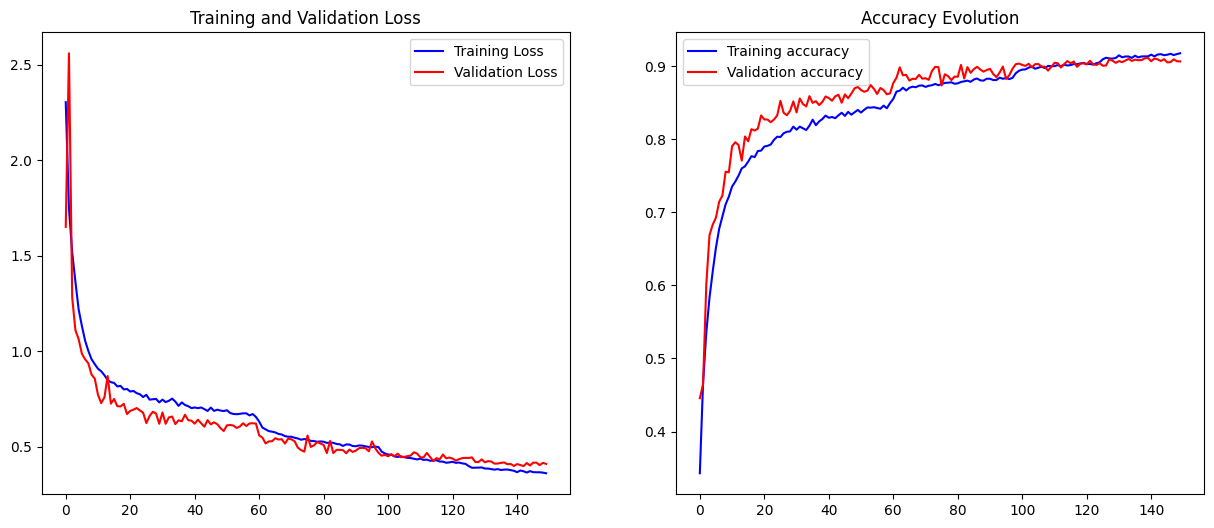

In [ ]:
plt.figure(figsize = (15,6))
plt.subplot(1,2,1)
plt.plot(model.history.history['loss'], label = 'Training Loss', color = 'blue')
plt.plot(model.history.history['val_loss'], label = 'Validation Loss',color = 'red')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1,2,2)
plt.plot(model.history.history['accuracy'], label = 'Training accuracy', color = 'blue')
plt.plot(model.history.history['val_accuracy'], label = 'Validation accuracy',color = 'red')
plt.legend()
plt.title('Accuracy Evolution')
plt.show()